# 03 -  ML Modelling

We would like to predict FPL player points for the following gameweek using the matrix of features built previously.

**Target variable:** 'next_gw_points' 

**Train set:** 2022-23, 2023-24, 2024-25  
**Test set:** 2025-26

In [2]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the feature matrix


In [5]:
con = sqlite3.connect("../db/fpl.db")

df = pd.read_sql("""
    SELECT *
    FROM player_gameweek_stats
""", con)

df = df.sort_values(['player_id', 'season', 'gameweek_id']).reset_index(drop=True)

df['next_gw_points'] = df.groupby(['player_id', 'season'])['total_points'].shift(-1)

df = df[df['next_gw_points'].notna()].reset_index(drop=True)

print(df.shape)
print(df['season'].value_counts().sort_index())


(101152, 33)
season
2022-23    24179
2023-24    27621
2024-25    26427
2025-26    22925
Name: count, dtype: int64


## 2. Rebuild features


In [6]:
# Rolling form — average points over last 3 and 5 gameweeks
df['form_3'] = (
    df.groupby(['player_id', 'season'])['total_points']
    .shift(1)
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(drop=True)
)

df['form_5'] = (
    df.groupby(['player_id', 'season'])['total_points']
    .shift(1)
    .rolling(5, min_periods=1)
    .mean()
    .reset_index(drop=True)
)

# Minutes per game this season so far
df['cumulative_minutes'] = df.groupby(['player_id', 'season'])['minutes'].cumsum()
df['cumulative_games'] = df.groupby(['player_id', 'season']).cumcount() + 1
df['minutes_per_game'] = df['cumulative_minutes'] / df['cumulative_games']

# Per 90 stats
df['goals_per_90'] = (df['goals_scored'] / df['minutes'].replace(0, np.nan)) * 90
df['assists_per_90'] = (df['assists'] / df['minutes'].replace(0, np.nan)) * 90
df['xg_per_90'] = (df['expected_goals'] / df['minutes'].replace(0, np.nan)) * 90
df['xa_per_90'] = (df['expected_assists'] / df['minutes'].replace(0, np.nan)) * 90

print("Features computed")
print(df.shape)


Features computed
(101152, 42)


## 3. Define the feature matrix and target

In [8]:
FEATURES = [
    'form_3',
    'form_5',
    'minutes_per_game',
    'goals_per_90',
    'assists_per_90',
    'xg_per_90',
    'xa_per_90',
    'was_home',
    'value',
]

TARGET = 'next_gw_points'

# Fill NaN in per 90 stats with 0 
model_df = df[FEATURES + [TARGET, 'season']].fillna(0)

print(model_df.shape)
print(model_df['season'].value_counts().sort_index())

(101152, 11)
season
2022-23    24179
2023-24    27621
2024-25    26427
2025-26    22925
Name: count, dtype: int64


## 4. Train/test split

In [10]:
train_df = model_df[model_df['season'] != '2025-26']
test_df = model_df[model_df['season'] == '2025-26']

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")

Train: 78227 rows
Test:  22925 rows


## 5. Linear Regression — baseline

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Linear Regression")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

Linear Regression
MAE:  1.066
RMSE: 2.012


## 6. Model Coefficients


In [12]:
coefficients = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)

print(coefficients.to_string(index=False))


         feature  coefficient
          form_3     0.160958
          form_5     0.145027
       xg_per_90     0.104293
       xa_per_90     0.072222
    goals_per_90     0.051064
  assists_per_90     0.025065
minutes_per_game     0.020934
           value     0.018104
        was_home    -0.070769


## 7. Coefficient chart

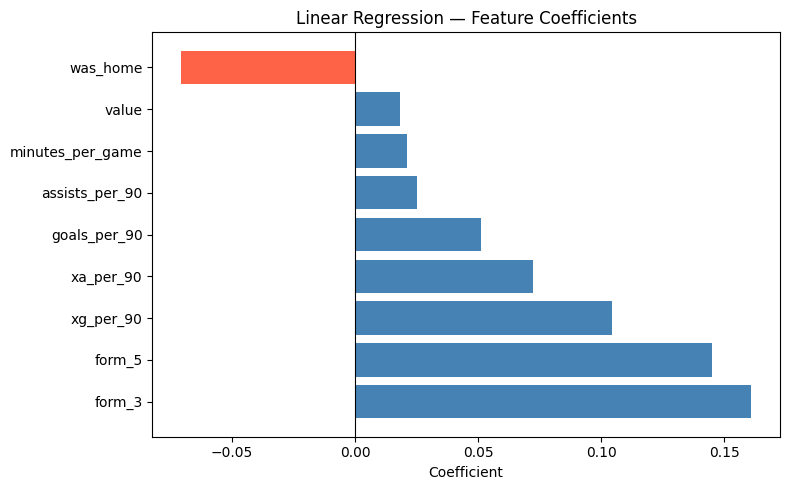

In [13]:
plt.figure(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coefficients['coefficient']]
plt.barh(coefficients['feature'], coefficients['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression — Feature Coefficients')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()


## 8. Ridge and Lasso Regression

In [14]:
from sklearn.linear_model import Ridge, Lasso

In [15]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

results = pd.DataFrame({
    'model': ['Linear Regression', 'Ridge', 'Lasso'],
    'MAE':  [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    'RMSE': [
        root_mean_squared_error(y_test, y_pred),
        root_mean_squared_error(y_test, y_pred_ridge),
        root_mean_squared_error(y_test, y_pred_lasso)
    ]
}).round(3)

print(results.to_string(index=False))

            model   MAE  RMSE
Linear Regression 1.066 2.012
            Ridge 1.066 2.012
            Lasso 1.067 2.003


### Which features did Lasso remove?

In [16]:
lasso_coef = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': lasso.coef_
}).sort_values('coefficient', ascending=False)

print(lasso_coef.to_string(index=False))


         feature  coefficient
          form_3     0.160359
          form_5     0.081182
minutes_per_game     0.023130
           value     0.020102
    goals_per_90     0.000000
  assists_per_90     0.000000
       xg_per_90     0.000000
       xa_per_90     0.000000
        was_home    -0.000000


Lasso zeroed out all the per 90 stats as well as the home advantage, suggesting that form is enough to measure for attacking output.

## 9. Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor


In [18]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

results = pd.DataFrame({
    'model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest'],
    'MAE':  [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mae_rf
    ],
    'RMSE': [
        root_mean_squared_error(y_test, y_pred),
        root_mean_squared_error(y_test, y_pred_ridge),
        root_mean_squared_error(y_test, y_pred_lasso),
        rmse_rf
    ]
}).round(3)

print(results.to_string(index=False))

            model   MAE  RMSE
Linear Regression 1.066 2.012
            Ridge 1.066 2.012
            Lasso 1.067 2.003
    Random Forest 1.003 1.973


### Random Forest - Feature Importance

         feature  importance
          form_3    0.473043
minutes_per_game    0.158210
           value    0.126116
       xa_per_90    0.108796
          form_5    0.054303
       xg_per_90    0.042857
    goals_per_90    0.015018
  assists_per_90    0.011985
        was_home    0.009671


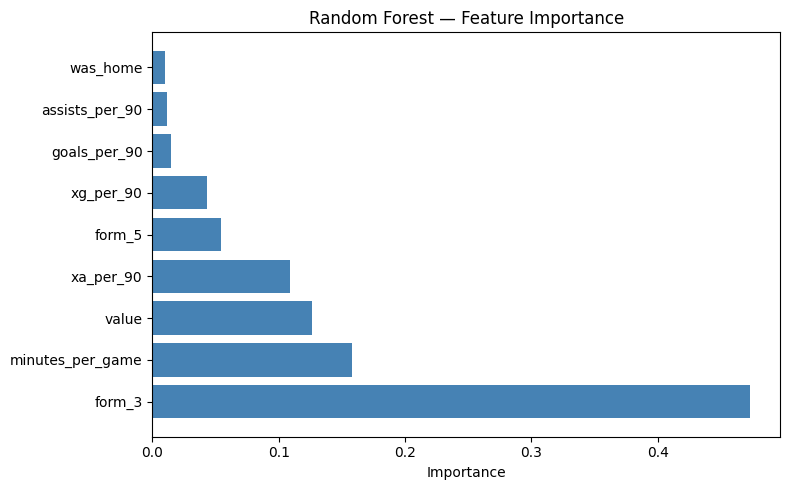

In [19]:
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 10. Neural Network

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=42
)

nn.fit(X_train_scaled, y_train)
y_pred_nn = nn.predict(X_test_scaled)

mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = root_mean_squared_error(y_test, y_pred_nn)

results = pd.DataFrame({
    'model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Neural Network'],
    'MAE':  [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mae_rf,
        mae_nn
    ],
    'RMSE': [
        root_mean_squared_error(y_test, y_pred),
        root_mean_squared_error(y_test, y_pred_ridge),
        root_mean_squared_error(y_test, y_pred_lasso),
        rmse_rf,
        rmse_nn
    ]
}).round(3)

print(results.to_string(index=False))

            model   MAE  RMSE
Linear Regression 1.066 2.012
            Ridge 1.066 2.012
            Lasso 1.067 2.003
    Random Forest 1.003 1.973
   Neural Network 1.072 2.021


c:\Users\Alban\fpl-analytics\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## 11. Final comparison and conclusions

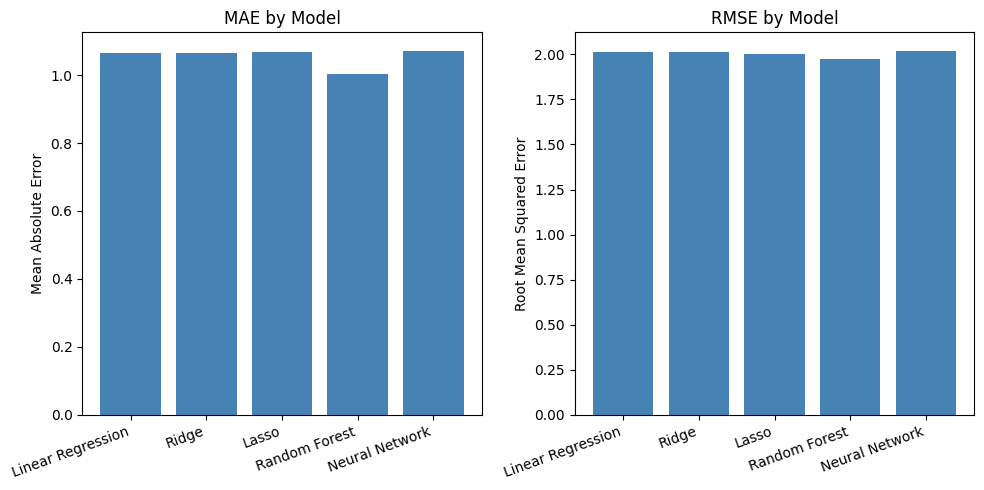

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

models = results['model']
x = range(len(models))

axes[0].bar(x, results['MAE'], color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha='right')
axes[0].set_title('MAE by Model')
axes[0].set_ylabel('Mean Absolute Error')

axes[1].bar(x, results['RMSE'], color='steelblue')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha='right')
axes[1].set_title('RMSE by Model')
axes[1].set_ylabel('Root Mean Squared Error')

plt.tight_layout()
plt.show()

## Conclusions

| Model | MAE | RMSE |
|---|---|---|
| Linear Regression | 1.066 | 2.012 |
| Ridge | 1.066 | 2.012 |
| Lasso | 1.067 | 2.003 |
| Random Forest | 1.003 | 1.973 |
| Neural Network | 1.072 | 2.021 |

**Random Forest is clearly the best model** with MAE of 1.003 and RMSE of 1.973.

**Key findings:**
- Recent form (`form_3`) is the strongest predictor of next gameweek points, with 47% of random forest feature importance
- Player availability (`minutes_per_game`) and price (`value`) are the next most important features
- Expected stats (`xa_per_90`, `xg_per_90`) outperform raw stats (`assists_per_90`, `goals_per_90`) 
- Interestingly, home advantage is not a meaningful predictor for individual FPL points. While home advantage is very real, it impacts game outcomes more than individual performances.
- Data is not complex enough for neural network

**Known limitations:**
- Opponent strength uses the 2025-26 team ratings applied to all historical seasons - clearly this is a problem. Teams can drastically change over the course of the season, and especially from season to season.
- Model will never be able to account for purely unpredictable events, ie. early subs due to injuries, jammy last minute goals...